# specextract

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 869

download_chandra_obsid 869
chandra_repro 869 out=`pwd` clob+


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      10 Kb  ####################          < 1 s  1770.5 kb/s
  oif      fits       25 Kb  ####################          < 1 s  3682.9 kb/s
  vv       pdf        41 Kb  ####################          < 1 s  5859.9 kb/s
  cntr_img fits      177 Kb  ####################          < 1 s  12465.9 kb/s
  cntr_img jpg       815 Kb  ####################          < 1 s  31979.9 kb/s
  evt2     fits       20 Mb  ####################          < 1 s  77299.6 kb/s
  full_img fits       88 Kb  ####################          < 1 s  10139.5 kb/s
  full_img jpg        74 Kb  ####################          < 1 s  8036.8 kb/s
  bpix     fits       38 Kb  ####################          < 1 s  5413.1 kb/s
  fov      fits        6 Kb  ####################          < 1 s  1011.1 kb/s
  eph1     fits      281 Kb  ####################          


## Build Regions

In [3]:
cat << EOM > simple.reg 
# Region file format: CIAO version 1.0
ellipse(4026,4138.9,50,40,0)
EOM

In [4]:
cat << EOM > simple_bkg.reg
# Region file format: CIAO version 1.0
circle(3955.5,4252.5,50)
EOM

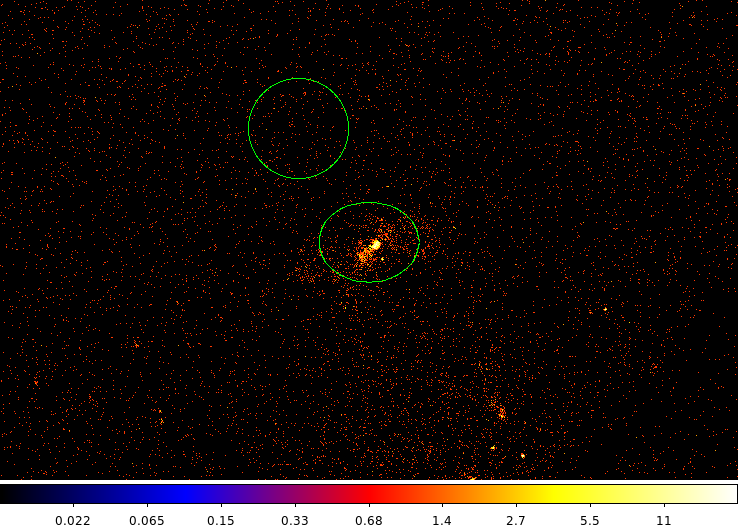

In [5]:
ds9 acisf00869_repro_evt2.fits -bin filter 'energy=500:7000' \
    -bin about 4025 4140 -cmap b -scale log -region simple.reg \
    -region simple_bkg.reg \
    -saveimage png ds9_01.png -quit

display < ds9_01.png

## Using `specextract`

In [6]:
punlearn specextract
pset specextract infile="acisf00869_repro_evt2.fits[sky=region(simple.reg)]"
pset specextract outroot=simple
pset specextract bkgfile="acisf00869_repro_evt2.fits[sky=region(simple_bkg.reg)]"
specextract mode=h clob+

Running specextract
Version: 30 November 2016

Checking for blank sky background files...
Using event file acisf00869_repro_evt2.fits[sky=region(simple.reg)]

Aspect solution file pcadf078246822N004_asol1.fits found.

Bad-pixel file acisf00869_repro_bpix1.fits found.

Mask file acisf00869_000N004_msk1.fits found.

Setting bad pixel file 

Extracting src spectra 

Creating src ARF 

Creating src RMF 

Using mkacisrmf...

Grouping src spectrum 

Updating header of simple.pi with RESPFILE and ANCRFILE keywords.

Updating header of simple_grp.pi with RESPFILE and ANCRFILE keywords.

Setting bad pixel file 

Extracting bkg spectra 

Creating bkg ARF 

Creating bkg RMF 

Using mkacisrmf...

Updating header of simple_bkg.pi with RESPFILE and ANCRFILE keywords.

Updating header of simple.pi with BACKFILE keyword.

Updating header of simple_grp.pi with BACKFILE keyword.



## Step by Step

### Extract spectra

In [7]:
punlearn dmextract
pset dmextract infile="acisf00869_repro_evt2.fits[sky=region(simple.reg)][bin pi]"
pset dmextract outfile=simple_steps.pi
pset dmextract wmap="[energy=300:2000][bin tdet=8]"
dmextract mode=h clob+


In [8]:
pset dmextract infile="acisf00869_repro_evt2.fits[sky=region(simple_bkg.reg)][bin pi]"
pset dmextract outfile=simple_steps_bkg.pi
dmextract mode=h clob+

### Calc Arfs


#### Aspect Histograms

In [9]:
cat acisf00869_asol1.lis

/data/sdsreg/thread_output/CIAO4.9/specextract/869/primary/pcadf078246822N004_asol1.fits


In [10]:
dmstat "acisf00869_repro_evt2.fits[sky=region(simple.reg)][cols ccd_id]"

ccd_id
    min:	7 	      @:	1 
    max:	7 	      @:	1 
   mean:	7 
  sigma:	0 
    sum:	17738 
   good:	2534 
   null:	0 



In [11]:
dmstat "acisf00869_repro_evt2.fits[sky=region(simple_bkg.reg)][cols ccd_id]"


ccd_id
    min:	7 	      @:	1 
    max:	7 	      @:	1 
   mean:	7 
  sigma:	0 
    sum:	10332 
   good:	1476 
   null:	0 



In [12]:
punlearn asphist
pset asphist infile=@acisf00869_asol1.lis
pset asphist outfile=simple_steps.asphist
pset asphist evtfile="acisf00869_repro_evt2.fits[ccd_id=7]"
asphist mode=h clob+


#### Create wmaps

In [13]:
punlearn sky2tdet
pset sky2tdet infile="acisf00869_repro_evt2.fits[sky=region(simple.reg)][energy=300:2000][bin sky=1]"
pset sky2tdet asphistfile="simple_steps.asphist"
pset sky2tdet outfile="simple_steps_tdet.fits[wmap]"
sky2tdet mode=h clob+


In [14]:
pset sky2tdet infile="acisf00869_repro_evt2.fits[sky=region(simple_bkg.reg)][energy=300:2000][bin sky=1]"
pset sky2tdet outfile="simple_steps_bkg_tdet.fits[wmap]"
sky2tdet mode=h clob+


#### Create arfs (mkwarf)

In [15]:
punlearn mkwarf
pset mkwarf infile="simple_steps_tdet.fits[wmap]"
pset mkwarf outfile=simple_steps.arf
pset mkwarf weightfile=simple_steps.wfef
pset mkwarf egridspec=0.3:11.0:0.01 
pset mkwarf mskfile=acisf00869_000N004_msk1.fits
mkwarf mode=h clob+


In [16]:
pset mkwarf infile="simple_steps_bkg_tdet.fits[wmap]"
pset mkwarf outfile=simple_steps_bkg.arf
pset mkwarf weightfile=simple_steps_bkg.wfef
mkwarf mode=h clob+


### Create RMFs

#### mkacisrmf

In [17]:
punlearn mkacisrmf
pset mkacisrmf infile=CALDB
pset mkacisrmf outfile=simple_steps_mkacisrmf.rmf
pset mkacisrmf energy=0.3:11.0:0.01
pset mkacisrmf channel=1:1024:1
pset mkacisrmf wmap="simple_steps.pi[WMAP]"
mkacisrmf mode=h clob+




Total 18 regions to be processed:
    1> reg# 1263  processed
    2> reg# 1264  processed
    3> reg# 1265  processed
    4> reg# 1266  processed
    5> reg# 1294  processed
    6> reg# 1295  processed
    7> reg# 1296  processed
    8> reg# 1297  processed
    9> reg# 1298  processed
   10> reg# 1326  processed
   11> reg# 1327  processed
   12> reg# 1328  processed
   13> reg# 1329  processed
   14> reg# 1330  processed
   15> reg# 1359  processed
   16> reg# 1360  processed
   17> reg# 1361  processed
   18> reg# 1391  processed



In [18]:
pset mkacisrmf outfile=simple_steps_bkg_mkacisrmf.rmf
pset mkacisrmf wmap="simple_steps_bkg.pi[WMAP]"
mkacisrmf mode=h clob+




Total 17 regions to be processed:
    1> reg# 1393  processed
    2> reg# 1394  processed
    3> reg# 1395  processed
    4> reg# 1424  processed
    5> reg# 1425  processed
    6> reg# 1426  processed
    7> reg# 1427  processed
    8> reg# 1456  processed
    9> reg# 1457  processed
   10> reg# 1458  processed
   11> reg# 1459  processed
   12> reg# 1488  processed
   13> reg# 1489  processed
   14> reg# 1490  processed
   15> reg# 1491  processed
   16> reg# 1521  processed
   17> reg# 1522  processed



#### mkrmf

In [19]:
punlearn mkrmf
pset mkrmf infile=CALDB
pset mkrmf outfile=simple_steps_mkrmf.rmf
pset mkrmf axis1="energy=0:1"
pset mkrmf axis2="pi=1:1024:1"
pset mkrmf weights=simple_steps.wfef
mkrmf mode=h clob+

In [20]:
pset mkrmf outfile=simple_steps_bkg_mkrmf.rmf
pset mkrmf weights=simple_steps_bkg.wfef
mkrmf mode=h clob+

## Update spectrum files

### Group

In [21]:
punlearn dmgroup
pset dmgroup infile=simple_steps.pi
pset dmgroup outfile=simple_steps_grp.pi
pset dmgroup grouptype=NUM_CTS 
pset dmgroup grouptypeval=15
pset dmgroup xcolumn=channel
pset dmgroup ycolumn=counts
dmgroup mode=h clob+

### Hedit

In [22]:
punlearn dmhedit
pset dmhedit operation=add filelist="" mode=h
dmhedit simple_steps.pi key=BACKFILE value=simple_steps_bkg.pi
dmhedit simple_steps.pi key=RESPFILE value=simple_steps_mkacisrmf.rmf
dmhedit simple_steps.pi key=ANCRFILE value=simple_steps_corr.arf
dmhedit simple_steps_grp.pi key=BACKFILE value=simple_steps_bkg.pi
dmhedit simple_steps_grp.pi key=RESPFILE value=simple_steps_mkacisrmf.rmf
dmhedit simple_steps_grp.pi key=ANCRFILE value=simple_steps.arf


In [23]:
dmhedit simple_steps_bkg.pi operation=add key=RESPFILE value=simple_steps_bkg_mkacisrmf.rmf
dmhedit simple_steps_bkg.pi operation=add key=ANCRFILE value=simple_steps_bkg.arf

## Extracting Multiple Spectra

In [24]:
/bin/rm -rf 1842 1843

download_chandra_obsid 1842,1843
chandra_repro 1842,1843 out= clob+


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      11 Kb  ####################          < 1 s  2038.9 kb/s
  oif      fits       23 Kb  ####################          < 1 s  3730.8 kb/s
  vv       pdf        44 Kb  ####################          < 1 s  6424.3 kb/s
  cntr_img fits      230 Kb  ####################          < 1 s  15553.6 kb/s
  cntr_img jpg       910 Kb  ####################          < 1 s  34516.7 kb/s
  evt2     fits       19 Mb  ####################          < 1 s  72942.7 kb/s
  full_img fits       91 Kb  ####################          < 1 s  10873.4 kb/s
  full_img jpg        74 Kb  ####################          < 1 s  9443.3 kb/s
  bpix     fits       12 Kb  ####################          < 1 s  2249.2 kb/s
  fov      fits        6 Kb  ####################          < 1 s  1065.9 kb/s
  eph1     fits      281 Kb  ####################          

In [25]:
reproject_obs 1842,1843 reproj/ clob+

Running reproject_obs
Version: 27 October 2016

Found 1842/repro/acisf01842_repro_evt2.fits
Found 1843/repro/acisf01843_repro_evt2.fits
Verifying 2 observations.
Calculating new tangent point.
New tangent point: RA=18h 32m 21.696s Dec=-10d 34' 41.484"

Observations to be reprojected:

  Obsid  Obs Date   Exp    DETNAM     SIM_Z    FP   Sepn   PA  
                   (ks)                (mm)    (K)   (')  (deg)
---------------------------------------------------------------
1 1843  2000-09-02   7.9 ACIS-012367 -245.857 153.4   2.6   -79
2 1842  2000-09-02   7.4 ACIS-012367 -231.239 153.4   2.6  +101

Running tasks in parallel with 4 processors.
Reprojecting 2 event files to a common tangent point.
Merging reprojected events files to reproj/merged_evt.fits

The following files were created:

The reprojected event files:
     reproj/1843_reproj_evt.fits
     reproj/1842_reproj_evt.fits

The merged event file:
     reproj/merged_evt.fits

   should not be used to create ARF/RMF/exposure ma

In [26]:
cat << EOM > 1842_src.reg
# Region file format: CIAO version 1.0
circle(1943.3,4164.2,102)
EOM

cat << EOM > 1843_src.reg
# Region file format: CIAO version 1.0
circle(1943.3,4164.2,135)
EOM

cat << EOM > 1842_bg.reg
# Region file format: CIAO version 1.0
circle(2259.3,4072.3,100)
EOM

cat << EOM > 1843_bg.reg
# Region file format: CIAO version 1.0
circle(2361.5,4104.8,140)
EOM


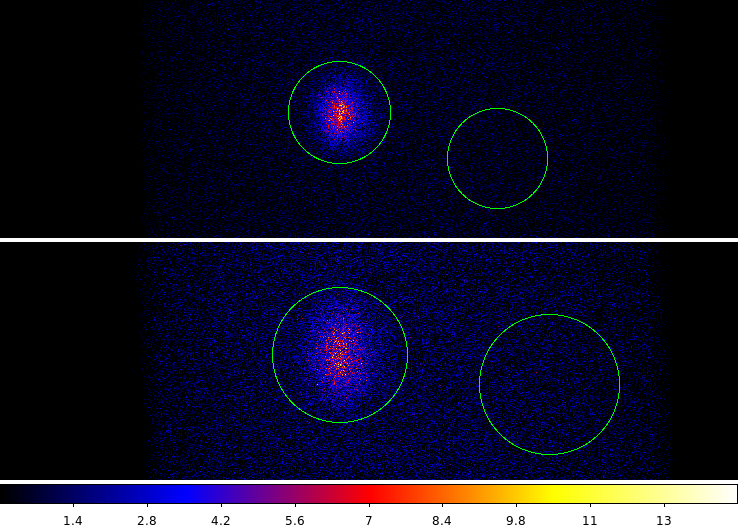

In [27]:
ds9 reproj/1842_reproj_evt.fits -bin filter 'energy=500:7000' \
  -bin about 2000 4150 -bin factor 2 -cmap b -region 1842_src.reg -region 1842_bg.reg \
  reproj/1843_reproj_evt.fits -bin filter 'energy=500:7000' \
  -bin about 2000 4150 -bin factor 2 -cmap b -region 1843_src.reg \
  -region 1843_bg.reg -tile row \
  -saveimage png ds9_02.png -quit

display < ds9_02.png 


### Run Specextract

In [28]:
cat << EOM > multi_src.lis
reproj/1842_reproj_evt.fits[sky=region(1842_src.reg)]
reproj/1843_reproj_evt.fits[sky=region(1843_src.reg)]
EOM


In [29]:
cat << EOM > multi_bg.lis
reproj/1842_reproj_evt.fits[sky=region(1842_bg.reg)]
reproj/1843_reproj_evt.fits[sky=region(1843_bg.reg)]
EOM

In [30]:
mkdir spec
punlearn specextract
pset specextract infile=@multi_src.lis
pset specextract outroot=spec/1842,spec/1843
pset specextract bkgfile=@multi_bg.lis
specextract mode=h clob+


mkdir: cannot create directory `spec': File exists
Running specextract
Version: 30 November 2016

Checking for blank sky background files...
Using event file reproj/1842_reproj_evt.fits[sky=region(1842_src.reg)]

Aspect solution file reproj/1842.asol found.

Bad-pixel file reproj/1842.bpix found.

Mask file reproj/1842.mask found.

Using event file reproj/1843_reproj_evt.fits[sky=region(1843_src.reg)]

Aspect solution file reproj/1843.asol found.

Bad-pixel file reproj/1843.bpix found.

Mask file reproj/1843.mask found.

Setting bad pixel file [1 of 2]

Extracting src spectra [1 of 2]

Creating src ARF [1 of 2]

Creating src RMF [1 of 2]

Using mkacisrmf...

Grouping src spectrum [1 of 2]

Updating header of spec/1842.pi with RESPFILE and ANCRFILE keywords.

Updating header of spec/1842_grp.pi with RESPFILE and ANCRFILE keywords.

Setting bad pixel file [2 of 2]

Extracting src spectra [2 of 2]

Creating src ARF [2 of 2]

Creating src RMF [2 of 2]

Using mkacisrmf...

Grouping src spec

### Examine outputs

In [31]:
ls -1 spec/*grp.pi

spec/1842_grp.pi
spec/1843_grp.pi


In [32]:
ls -1 spec/184?.pi

spec/1842.pi
spec/1843.pi


In [33]:
ls -1 spec/*bkg.pi

spec/1842_bkg.pi
spec/1843_bkg.pi


In [34]:
ls -1 spec/*arf

spec/1842.arf
spec/1842_bkg.arf
spec/1843.arf
spec/1843_bkg.arf


In [35]:
ls -1 spec/*rmf

spec/1842.rmf
spec/1842_bkg.rmf
spec/1843.rmf
spec/1843_bkg.rmf


## Fitting

read ARF file simple.arf
read RMF file simple.rmf
read ARF (background) file simple_bkg.arf
read RMF (background) file simple_bkg.rmf
read background file simple_bkg.pi


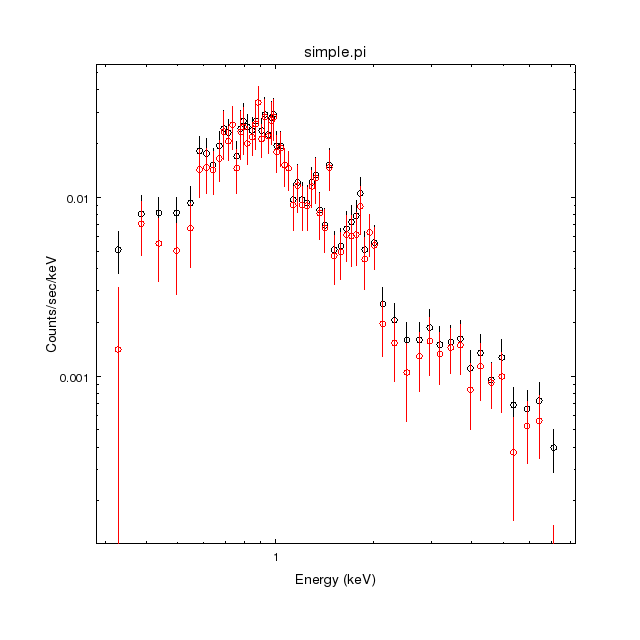

In [36]:
cat << EOM > s1.py
load_data('simple.pi')
notice(0.3, 7)
group_counts(20)
plot_data()
log_scale()
subtract()
plot_data(overplot=True)
set_curve(['*.color', 'red'])
print_window("sherpa_01.png","export.clobber=True")
quit()
EOM

sherpa -n s1.py
display < sherpa_01.png

In [ ]:
/bin/rm -rf 1842 1843 869
/bin/rm -f acisf*fits pcadf*fits
mv -fv spec/* ./
mv -fv reproj/merged_evt.fits ./
/bin/rm -rf reproj
